# COE 311K Final Project - Part 2 of 3 by Vishnu Prasad (vp9439)

## Section 1: Introduction & System Selection

Let's consider a highly damped mechanical system, modeled after an overdamped spring-mass system with a slowly varying external force. To simplify this system, we will assume negligible mass to convert the second-order system into a first-order differential equation. 

### This is the governing ODE for the mechanical system:
## $\frac{dx}{dt} = -\frac{k}{c}x + \frac{1}{c}F(t)$

### These parameters will be used:

$\frac{k}{c}$ = $5000 s^{-1}$ (damping rate) 

$F(t)$ = $10sin(t) N$ 

### Rewriting the equation:

## $\frac{dx}{dt} = -5000x + 0.002sin(t)$

### Physical meanings of variables and parameters:

$x(t)$  = displacement from equilibrium (m)

$t$ = time (s)

$k$ = spring constant (N/m)

$c$ = damping coefficient (N·s/m)

$F(t)$ = external force function (N)

Physically, the high damping rate will force the mechanical system to return to equilibrium quickly while the external force provides slow dynamics once the system reaches equilibrium. 

### Initial Condition:

## $x(0) = 1 m$

We will assume an initial condition x(0) = 1, representing an initial displacement of 1 m from equilibrium in the spring-mass system. 

### Importance of the system:

Overdamped mechanical systems have broad applications, including shock absorbers, vibration dampers, and seismic isolation. Since these system incorporate both fast and slow dynamics, they are numerically stiff, which means that explicit methods such as Euler's Forward will require extremely small step sizes to be stable. This is inefficient, so implicit methods such as Euler's Backward must be used instead to solve stiff equations. 

First, we will apply Euler's Forward to demonstrate stiffness before implementing Euler's Backward (Implicit Euler) method using Newton-Raphson iteration to solve the residual equation at each time step.

## Section 2: Demonstration of Stiffness

<ipython-input-5-8eb8022fa724>:12: RuntimeWarning: overflow encountered in double_scalars
  return -5000*x + 0.002*np.sin(t)
<ipython-input-5-8eb8022fa724>:25: RuntimeWarning: invalid value encountered in double_scalars
  x_values[i] = x_values[i-1] + h * f(t_values[i-1], x_values[i-1])


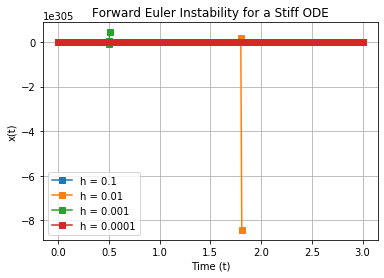

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
x0 = 1 # Initial position (m)
t0 = 0 # Start time (s)
tf = 3 # End time (s)
h_values = np.array([0.1, 0.01, 0.001, 0.0001]) # Step sizes

# Function representing dx/dt
def f(t, x):
    return -5000*x + 0.002*np.sin(t)

# Forward Euler method
def forward_euler(f, x0, t0, tf, h):
    # Create arrays to store t and y values
    t_values = np.arange(t0, tf + h, h)
    x_values = np.zeros_like(t_values)
    
    # Set initial condition
    x_values[0] = x0
    
    # Euler's Method loop
    for i in range(1, len(t_values)):
        x_values[i] = x_values[i-1] + h * f(t_values[i-1], x_values[i-1])
    
    return t_values, x_values

# Solve using Forward Euler
for h in h_values:
    # Get t and x values from Euler's Method
    t_values_fe, x_values_fe = forward_euler(f, x0, t0, tf, h)
    plt.plot(t_values_fe, x_values_fe, 's-', label=f'h = {h}')

# Plot x(t) vs time
plt.xlabel('Time (t)')
plt.ylabel('x(t)')
plt.title('Forward Euler Instability for a Stiff ODE')
plt.legend()
plt.grid(True)
plt.show()

We attempted to solve the system using Euler's Forward Method for various step sizes. However, only the solution with the smallest step size, h = 0.0001, was stable, demonstrating that explicit methods require unreasonably small step sizes to converge.

We can verify stiffness by estimating the stiffness ratio, which is the ratio of fastest to slowest time scales. The fastest time scale is $\frac{1}{5000} = 2 * 10^{-4} s$, coming from the homogenous -5000x term of $\frac{dx}{dt} = -5000x + 0.002sin(t)$. The slowest time scale comes from the forcing term, sin(t), which has a period that varies in terms of full seconds, giving it a time scale of 1. Therefore, the stiffness ratio is $\frac{1}{2*10^{-4}} = 5000$. This large stiffness ratio confirms that the system is stiff.

The stability condition for Euler's Forward is |1 + hλ| ≤ 1, which simplifies to h < $\frac{2}{|λ|}$. Since the forcing term does not affect stability, we can assume λ = -5000 from $\frac{dx}{dt} = -5000x$. Therefore, the maximum step size required for Euler's Forward stability is 0.0004. For a total runtime of 3 seconds, this would require 7500 steps. The time complexity of Euler's Forward is O(n), so with such a small step size required, Euler's Forward becomes increasingly computationally expensive with larger timeframes. To resolve the issues with Euler's Forward, we must implement implicit solution methods.

## Section 3: Mathematical Setup

Let's define a residual function $g(x_{n+1})$:

## $g(x_{n+1}) = x_{n+1} - x_{n} - h(-5000x_{n+1} + 0.002sin(t_{n+1}))$

Then, $g'(x_{n+1})$ can be analytically derived:

## $g'(x_{n+1}) = 1 + 5000h$

Newton-Raphson Update Formula to solve $g(x_{n+1}) = 0$:

## $x_{n+1}^{(k+1)} = x_{n+1}^{(k)} - \frac{g(x_{n+1}^{(k)})}{g'(x_{n+1}^{(k)})}$

By substituting the residual function and its derivative:

## $x_{n+1}^{(k+1)} = x_{n+1}^{(k)} - \frac{x_{n+1}^{(k)} - x_{n} - h(-5000x_{n+1}^{(k)} + 0.002sin(t_{n+1}))}{1 + 5000h}$

## Section 4: Implementation

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Governing ODE function
def f(t, x):
    return -5000*x + 0.002*np.sin(t)   

# Newton-Raphson function
def newton_raphson(g, dg, x0, tol=1e-6, max_iter=20):
    # Initial guess
    x = x0
    
    # Newton-Raphson loop
    for i in range(max_iter):
        # Compute next iteration
        x_new = x - g(x) / dg(x)
        
        # Check for convergence
        if abs(x_new - x) < tol:
            return x_new, i + 1
        
        # Update x
        x = x_new

    return None, max_iter

# Backward Euler with Newton-Raphson
def backward_euler_newton(f, x0, t0, tf, h):
    # Create arrays to store t, x, and iteration count
    t_values = np.arange(t0, tf + h, h)
    x_values = np.zeros_like(t_values)
    iter_values = np.zeros_like(t_values)
    
    # Set initial conditions
    x_values[0] = x0
    iter_values[0] = 0
    
    # Backward Euler loop
    for i in range(1, len(t_values)):
        # Current values
        t_next = t_values[i]
        x_prev = x_values[i - 1]
        
        # Define g and dg for Newton-Raphson
        g = lambda x_next: x_next - x_prev - h * f(t_next, x_next)
        dg = lambda x_next: 1 + 5000*h
        
        
        x_guess = x_prev + h * f(t_values[i-1], x_prev) # Initial guess using explicit Euler predictor
        x_next, iterations = newton_raphson(g, dg, x_guess) # Solve x_(n+1) through NR
        
        # Error handling
        if x_next is None:
            raise RuntimeError(f"Newton failed at step {i}")
        
        # Store x and iteration count
        x_values[i] = x_next
        iter_values[i] = iterations
        
    return t_values, x_values, iter_values

# Parameters
x0 = 1
t0 = 0
tf = 3
h_values = np.array([0.001, 0.01, 0.1, 0.5])

## Section 5: Results & Analysis / Performance Analysis

At h = 0.001:
Total number of time steps: 1000.0
Average Newton-Raphson iterations per step: 1.0026657780739754
Total function evaluations: 3009.0

At h = 0.01:
Total number of time steps: 100.0
Average Newton-Raphson iterations per step: 1.0132890365448506
Total function evaluations: 305.0

At h = 0.1:
Total number of time steps: 10.0
Average Newton-Raphson iterations per step: 1.096774193548387
Total function evaluations: 34.0

At h = 0.5:
Total number of time steps: 2.0
Average Newton-Raphson iterations per step: 1.2857142857142858
Total function evaluations: 9.0



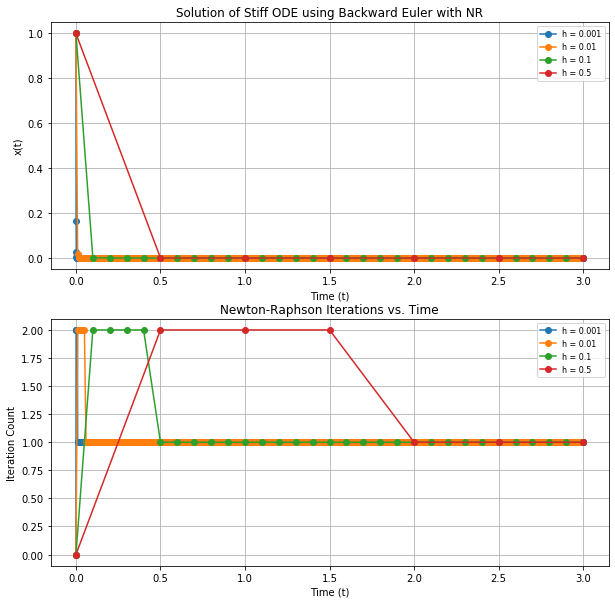

In [3]:
fig, axs = plt.subplots(2, 1, figsize=(10, 10))
for h in h_values:
    # Solve the ODE
    t_values_nl, x_values_nl, iter_values = backward_euler_newton(f, x0, t0, tf, h)
    
    # Computational expense stats
    print(f'At h = {h}:')
    print(f'Total number of time steps: {1/h}')
    print(f'Average Newton-Raphson iterations per step: {np.mean(iter_values)}')
    print(f'Total function evaluations: {np.sum(iter_values)}\n')
    
    axs[0].plot(t_values_nl, x_values_nl, 'o-', label=f'h = {h}')
    axs[1].plot(t_values_nl, iter_values, 'o-', label=f'h = {h}')
    
# Plot the results
axs[0].set_title('Solution of Stiff ODE using Backward Euler with NR')
axs[0].set_xlabel('Time (t)')
axs[0].set_ylabel('x(t)')

axs[1].set_title('Newton-Raphson Iterations vs. Time')
axs[1].set_xlabel('Time (t)')
axs[1].set_ylabel('Iteration Count')

for ax in axs:
    ax.legend(fontsize=8)
    ax.grid()

plt.show()

The maximum theoretical stable step size for Euler's Forward, as derived in the demonstration of stiffness, is h = 0.0004. On the other hand, Backward Euler is A-stable for linear systems, which means that it is unconditionally stable for any step size of this ODE. 

Step Size | Forward Euler | Backward Euler
---:|:---:| ---
**0.00001** | Stable | Stable
**0.0001** | Stable | Stable
**0.001** | Unstable | Stable
**0.01** | Unstable | Stable
**0.1** | Unstable | Stable

### Computational Cost:

In terms of computational cost, Euler's Forward requires a much higher total number of time steps compared to Euler's Backward since Euler's Backward is stable at larger h values. The tradeoff of Euler's Backward is that it typically requires more function evaluations per step than Euler's Forward since a nonlinear equation must be solved using Newton-Raphson iteration at each time step. 

Due to the linearity of this particular ODE, Newton-Raphson is usually able to converge in 1 iteration as shown in the iterations vs. time plot. Therefore, the dominant computational cost lies in step size rather than complex function evalutations, which makes Euler's Backward much less computationally expensive than Euler's Forward.

### Convergence Behavior:

Looking at the Newton-Raphson iterations vs. time plot above, we can see that with higher step sizes, the average amount of iterations per time step slightly increases. This is because as step size increases, the residual increases in the implicit equation, so the Newton-Raphson method needs more correction per iteration to resolve the larger residual. 

Additionally, the quality of the initial guess is a strong factor in convergence speed. In this implementation, we used Euler's Forward to to compute the initial guess, which provides a good approximation of the next step, keeping the iteration count at or under two iterations per time step.

Newton-Raphson typically requires more iterations to solve nonlinear systems due to curvature in the residual function. However, since this particular system is linear, its residual function and derivative is linear, meaning that Newton-Raphson is able to converge in a single iteration. Therefore, nonlinearity does not significantly affect convergence in this scenario.

### Analytical Solution:

### $x(t) = e^{-5000t} + (\frac{0.002*5000}{5000^2+1})sin(t) - (\frac{0.002}{5000^2+1})cos(t)$

Let's evaluate solution quality by plotting errors for different step sizes.

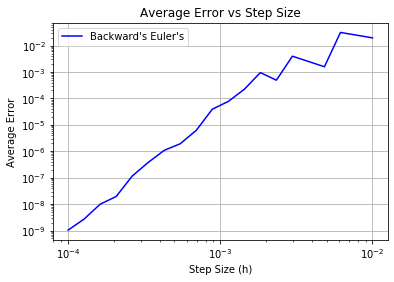

In [4]:
# Exact equation function
def x_exact(t):
    denom = 5000**2 + 1
    A = 0.002 * 5000 / denom
    B = -0.002 / denom
    C = 1 - B   # enforce x(0) = 1

    return C * np.exp(-5000*t) + A * np.sin(t) + B * np.cos(t)

h_values = np.logspace(-4, -2, 20) # Slightly smaller h to capture dynamics
error = []

for h in h_values:
    t_num, x_num, _ = backward_euler_newton(f, x0, t0, tf, h)
    
    # Calculate exact solution ONLY at the points the solver used
    x_ex = x_exact(t_num)
    
    # Only calculate error after the fast decay is gone (t > 0.005)
    mask = t_num > 0.005 
    error.append(np.max(np.abs(x_ex[mask] - x_num[mask])))

# Plot
plt.loglog(h_values, error, color = 'blue', label = 'Backward\'s Euler\'s')
plt.xlabel('Step Size (h)')
plt.ylabel('Average Error')
plt.title('Average Error vs Step Size')
plt.legend()
plt.grid(True)
plt.show()

### Verification of Solution Quality:

The solution always remains in physical bounds since Backward Euler is A-stable, so it won't blow up into non-physical / negative values. 

The fast transient is the $e^{-5000t}$ term in the analytical solution which constitutes the initial drop. At small step sizes, such as 0.001, the solver is able to resolve this portion of the graph, while at large step sizes, the solution skips to the stabilized state which misses the details of the fast transient.

The slow dynamics occur due to the 0.002sin(t) term once the fast transient dies out. From the error plot, we can notice that the average error decreases linearly as the step size decreases, which is verification that the system has reached a steady-state with expected first-order truncation error.
 
## Section 6: Conclusions

Throughout the analysis of this stiff equation, we implemented Euler's Forward to showcase stiffness before implementing Euler's Backward with Newton-Raphson iteration to solve the ODE with a reasonable step size. Euler's Forward, while possibly accurate with very small step sizes, was also extremely inefficient due to its instability with stiff equations. On the other hand, with Euler's Backward, there is a real tradeoff between accuracy and efficiency based on the chosen step size. 

One practical recommendation is to use explicit methods such as Euler's Forward for non-stiff equations where the stability condition allows for a large enough step size. Otherwise, if an equation cannot be reasonably solved with explicit methods, implicit methods such as Euler's Backward should be implemented to allow for a greater range of stability.